# SARIMAX Model and Residuals

### **PREPARATION: Library Setup and Installation**

- **Numpy (np)** - For Math functions.
- **Pandas (pd)** - Mass data structuring tool.
- **Warnings** - Bypasses annoying warnings (for visuals only).
- **SARIMAX (statsmodels)** - Statistical forecasting algorithm.

In [ ]:
!pip install -q statsmodels pmdarima scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
np.random.seed(42)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

## **DATASET PREPARATION**

**Well-Milled Rice**
- Gathered from Department of Agricultures public retail price monitoring on different agri-fisheries products
- Rice data gathered spans 2020-2026 which is the most complete/consistently documented.

In [ ]:
# GDrive Folder: Well-Milled Rice Price
file_id = '1yoqJdpuo7_QazvbQtu1s8woJ5fokNuLW'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

In [ ]:
df_raw_rice = pd.read_csv(url)
print('Raw shape:', df_raw_rice.shape)

print(df_raw_rice.head(20))

Raw shape: (2312, 3)
         Date  Well-Milled Low  Well-Milled High
0    1/1/2020             -1.0              -1.0
1    1/2/2020             32.0              44.0
2    1/3/2020             32.0              49.0
3    1/4/2020             32.0              44.0
4    1/5/2020             -1.0              -1.0
5    1/6/2020             32.0              44.0
6    1/7/2020             32.0              44.0
7    1/8/2020             32.0              44.0
8    1/9/2020             32.0              44.0
9   1/10/2020             32.0              44.0
10  1/11/2020             32.0              44.0
11  1/12/2020             -1.0              -1.0
12  1/13/2020             32.0              44.0
13  1/14/2020             32.0              44.0
14  1/15/2020             32.0              44.0
15  1/16/2020             32.0              44.0
16  1/17/2020             32.0              44.0
17  1/18/2020             32.0              44.0
18  1/19/2020             -1.0              -1.0

**ENSO Index**
- Oceanic Niño Index (ONI) sourced from the World Bank Group, which spans from January 1950 up until January 2026 in the Philippines
- Primary indicator for ENSO (El Niño-Southern Oscillation) activity. Classifies El Niño and La Niña events.

In [ ]:
# GDrive Folder: ENSO Index
file_id = '1nPFOljizaCxwNvLmXeFe4SKPMJFhbVmM'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

In [ ]:
df_raw_enso = pd.read_csv(url)
print('Raw shape:', df_raw_enso.shape)

print(df_raw_enso.head(20))

Raw shape: (916, 3)
        Date  ONI value      ONI Type
0   1950-Jan      -1.53       La Niña
1   1950-Feb      -1.34       La Niña
2   1950-Mar      -1.16       La Niña
3   1950-Apr      -1.18       La Niña
4   1950-May      -1.07       La Niña
5   1950-Jun      -0.85       La Niña
6   1950-Jul      -0.54       La Niña
7   1950-Aug      -0.42  ENSO Neutral
8   1950-Sep      -0.39  ENSO Neutral
9   1950-Oct      -0.44  ENSO Neutral
10  1950-Nov      -0.60       La Niña
11  1950-Dec      -0.80       La Niña
12  1951-Jan      -0.82       La Niña
13  1951-Feb      -0.54       La Niña
14  1951-Mar      -0.17  ENSO Neutral
15  1951-Apr       0.18  ENSO Neutral
16  1951-May       0.36  ENSO Neutral
17  1951-Jun       0.58       El Niño
18  1951-Jul       0.70       El Niño
19  1951-Aug       0.89       El Niño


## **PREPROCESSING STEPS**

**Well-Milled Rice Price**
- It has periodic 2 day gaps on every weekend, and doesn’t record on holidays or on random days.
- To account for missing data, use a combination of forward filling (FF) and backward filling (BF) on short missing days. To account for the large chunk of data missing, the researchers will use data interpolation..

In [ ]:
# Parse date column from string format
df_raw_rice['Date'] = pd.to_datetime(df_raw_rice['Date'])
df_raw_rice = df_raw_rice.sort_values('Date').reset_index(drop=True)

# Sets date as primary column
df_raw_rice.set_index('Date', inplace=True)

# Replace -1 (missing data) with NaN
df_raw_rice.replace(-1, np.nan, inplace=True)

print(f'\nDate range: {df_raw_rice.index.min().date()} to {df_raw_rice.index.max().date()}')
print(f'Total daily rows: {len(df_raw_rice)}')


Date range: 2020-01-01 to 2026-04-30
Total daily rows: 2312


In [ ]:
df_rice_daily = df_raw_rice.copy()

# Fills missing data via: Linear Interpolation -> Forward Fill -> Backward Fill
for col in ['Well-Milled Low', 'Well-Milled High']:
    df_rice_daily[col] = (
        df_rice_daily[col]
        .interpolate(method='linear', limit_direction='both')
        .ffill()
        .bfill()
    )

# Compute daily average price
df_rice_daily['Well-Milled Avg'] = (df_rice_daily['Well-Milled Low'] + df_rice_daily['Well-Milled High']) / 2

print(f'\nFinal dataset shape (rows, columns): {df_rice_daily.shape}')

df_rice_daily.head(20)


Final dataset shape (rows, columns): (2312, 3)


,Well-Milled Low,Well-Milled High,Well-Milled Avg
Date,,,
2020-01-01,32.0,44.0,38.0
2020-01-02,32.0,44.0,38.0
2020-01-03,32.0,49.0,40.5
2020-01-04,32.0,44.0,38.0
2020-01-05,32.0,44.0,38.0
2020-01-06,32.0,44.0,38.0
2020-01-07,32.0,44.0,38.0
2020-01-08,32.0,44.0,38.0
2020-01-09,32.0,44.0,38.0


**ENSO Index**
- Integrate the ENSO (El Niño-Southern Oscillation) Index into a daily interval.
- Adjust monthly values to match the daily frequency of the rice price data.
- Distribute across every day of its respective month, essentially treating the monthly state as a constant environmental baseline.

In [ ]:
# Parse date column from string format
df_raw_enso['Date'] = pd.to_datetime(df_raw_enso['Date'])
df_raw_enso = df_raw_enso.sort_values('Date').reset_index(drop=True)

# Sets date as primary column
df_raw_enso.set_index('Date', inplace=True)

# Filter df_raw_enso from January 2020 onwards
df_enso_filtered = df_raw_enso[df_raw_enso.index >= '2020-01-01'].copy()

# Forward fill monthly frequency to daily frequency
start_date_enso = df_enso_filtered.index.min()
end_date_enso = df_enso_filtered.index.max() + pd.offsets.MonthEnd(0)

daily_index = pd.date_range(start=start_date_enso, end=end_date_enso, freq='D')

df_enso_daily = df_enso_filtered.reindex(daily_index)
df_enso_daily = df_enso_daily.ffill()

print(f'\nFinal dataset shape (rows, columns): {df_enso_daily.shape}')


Final dataset shape (rows, columns): (2312, 2)


### **DATA VISUALIZATION**

**Well-Milled Rice Price** visualization across Low, High, and Mean of Low and High.

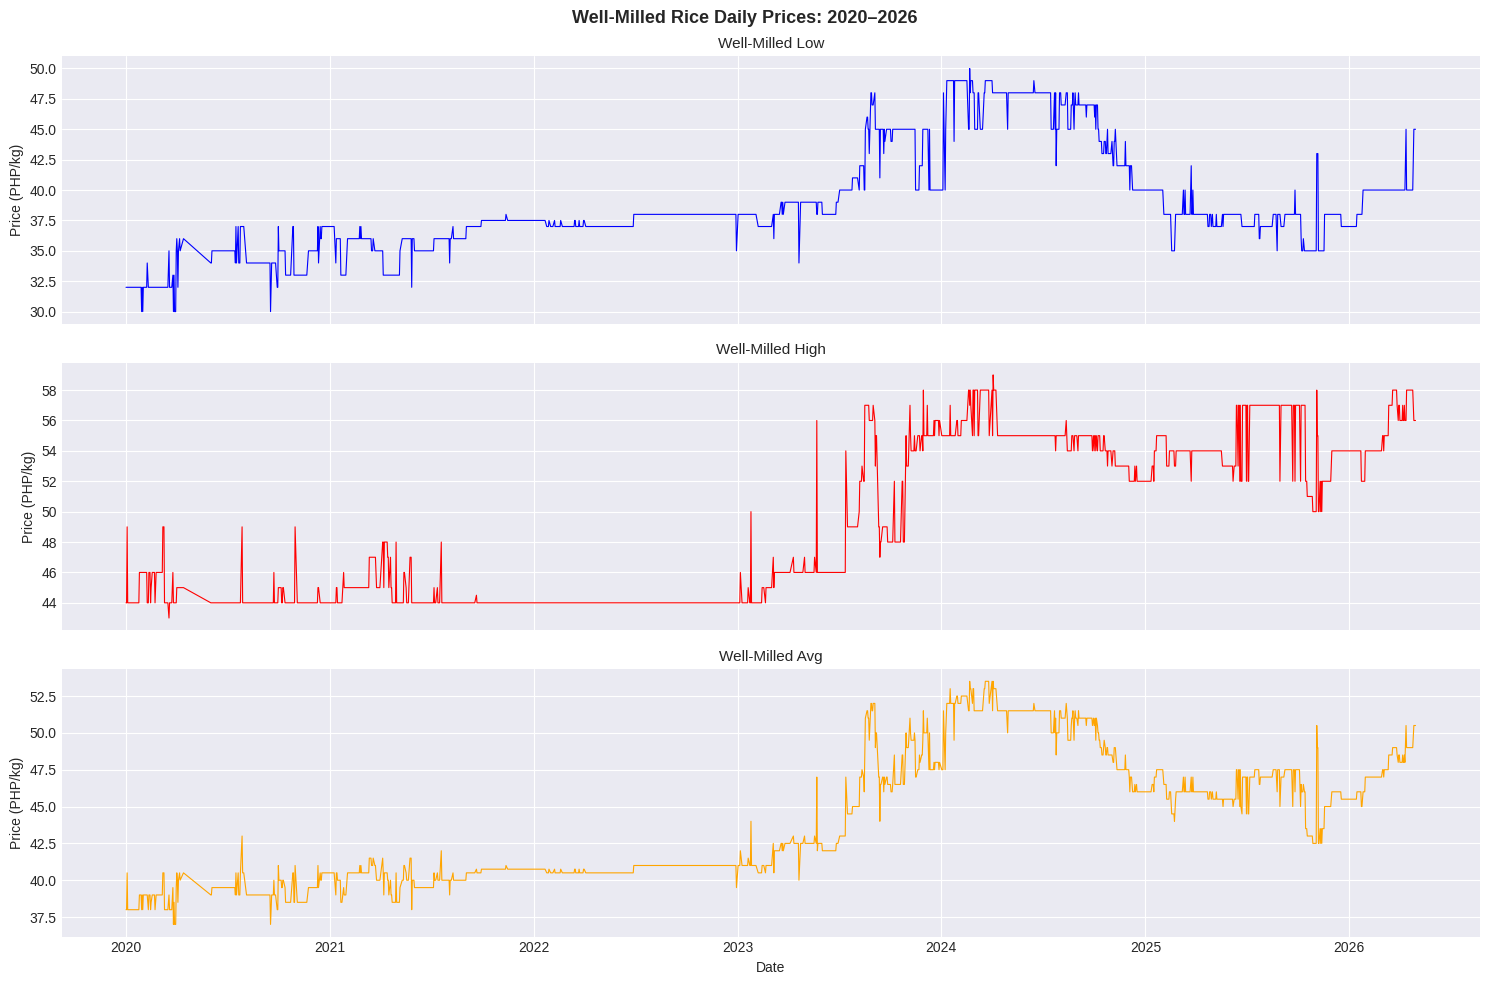

In [ ]:
# Plot full daily time series
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
TARGETS = ['Well-Milled Low', 'Well-Milled High', 'Well-Milled Avg']
colors  = ['blue', 'red', 'orange']

for ax, col, color in zip(axes, TARGETS, colors):
    ax.plot(df_rice_daily.index, df_rice_daily[col], color=color, linewidth=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Price (PHP/kg)')

axes[-1].set_xlabel('Date')
plt.suptitle('Well-Milled Rice Daily Prices: 2020–2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**ENSO Index** visualization across 2020 until 2026.

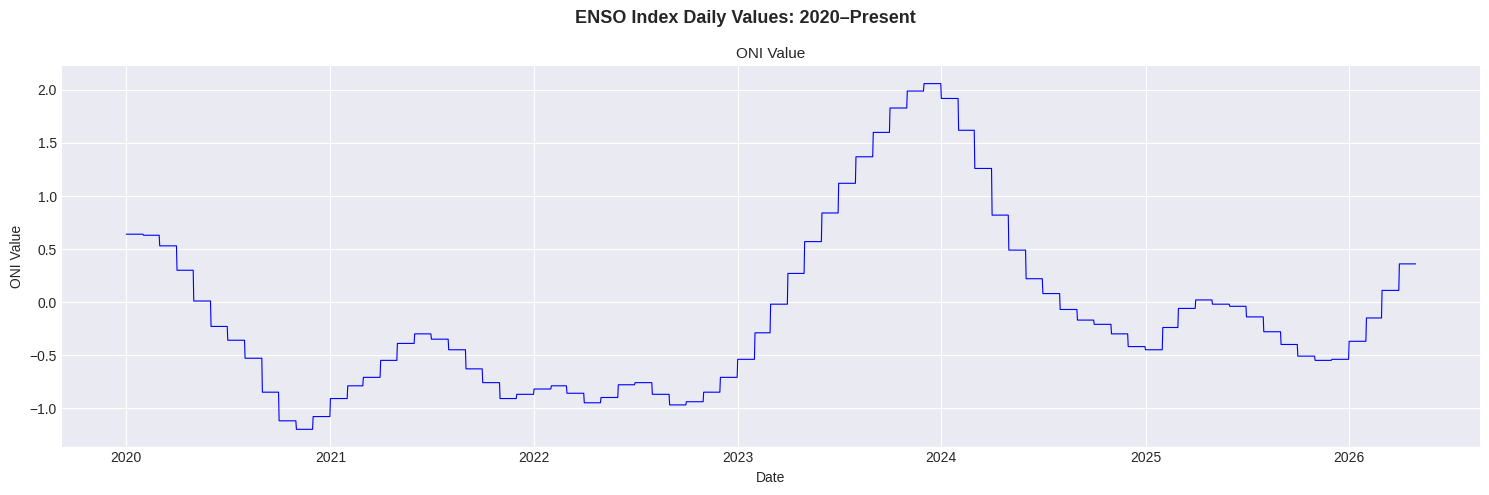

In [ ]:
# Plot full daily time series for ENSO Index
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_enso_daily.index, df_enso_daily['ONI value'], color='blue', linewidth=0.8)
ax.set_title('ONI Value', fontsize=11)
ax.set_ylabel('ONI Value')

ax.set_xlabel('Date')
plt.suptitle('ENSO Index Daily Values: 2020–Present', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## **SARIMAX MODEL**

#### _Data splitting - splitting the dataset into training set (70), validation set (20), and testing set (10)_

In [ ]:
# 70-20-10 split
train_split_count = 0.7
validation_split_count = 0.2

# Row split calculation for training - validation - testing
total_rows = len(df_rice_daily)

train_size = int(total_rows * train_split_count)
val_size = int(total_rows * validation_split_count)
test_size = total_rows - train_size - val_size

# Split rice price data
train_rice_df = df_rice_daily.iloc[:train_size].copy()
val_rice_df = df_rice_daily.iloc[train_size : train_size + val_size].copy()
test_rice_df = df_rice_daily.iloc[train_size + val_size:].copy()

# Split ENSO data (exogeneous variable)
train_enso_df = df_enso_daily.iloc[:train_size][['ONI value']].copy()
val_enso_df = df_enso_daily.iloc[train_size : train_size + val_size][['ONI value']].copy()
test_enso_df = df_enso_daily.iloc[train_size + val_size:][['ONI value']].copy()

print('==== WELL-MILLED RICE ====')
print(f'Training period: {train_rice_df.index.min().date()} to {train_rice_df.index.max().date()} (n={len(train_rice_df)} rows)')
print(f'Validation period: {val_rice_df.index.min().date()} to {val_rice_df.index.max().date()} (n={len(val_rice_df)} rows)')
print(f'Testing period : {test_rice_df.index.min().date()} to {test_rice_df.index.max().date()} (n={len(test_rice_df)} rows)')

print('\n==== ENSO INDEX ====')
print(f'Training period: {train_enso_df.index.min().date()} to {train_enso_df.index.max().date()} (n={len(train_enso_df)} rows)')
print(f'Validation period: {val_enso_df.index.min().date()} to {val_enso_df.index.max().date()} (n={len(val_enso_df)} rows)')
print(f'Testing period : {test_enso_df.index.min().date()} to {test_enso_df.index.max().date()} (n={len(test_enso_df)} rows)')

==== WELL-MILLED RICE ====
Training period: 2020-01-01 to 2024-06-05 (n=1618 rows)
Validation period: 2024-06-06 to 2025-09-10 (n=462 rows)
Testing period : 2025-09-11 to 2026-04-30 (n=232 rows)

==== ENSO INDEX ====
Training period: 2020-01-01 to 2024-06-05 (n=1618 rows)
Validation period: 2024-06-06 to 2025-09-10 (n=462 rows)
Testing period : 2025-09-11 to 2026-04-30 (n=232 rows)


**Parameter selection. Selects order and seasonal order from SARIMAX(p, d, q)*(P, D, Q, s).**
1. Order: (p, d, q)
2. Seasonal order: (P, D, Q, s)

In [ ]:
sarimax_orders = {}

FORECAST_TARGETS = ['Well-Milled Low', 'Well-Milled High']
BEST_PARAMS = {
    "Well-Milled Low": ((0, 0, 0), (2, 1, 0, 7)),
    "Well-Milled High": ((0, 0, 0), (0, 1, 0, 7))
}
TARGET_COLORS = ['blue', 'purple']

for target in FORECAST_TARGETS:
    print(f'\n[{target}] Selecting SARIMAX orders...')

    # Pass endogenous and exogenous variables
    order, seasonal_order = BEST_PARAMS[target]
    sarimax_orders[target] = (order, seasonal_order)

print('\nSelected SARIMAX orders:')
print(sarimax_orders)


[Well-Milled Low] Selecting SARIMAX orders...

[Well-Milled High] Selecting SARIMAX orders...

Selected SARIMAX orders:
{'Well-Milled Low': ((0, 0, 0), (2, 1, 0, 7)), 'Well-Milled High': ((0, 0, 0), (0, 1, 0, 7))}


**Fitting SARIMAX model on Well-Milled Rice High and Low Prices**
- Endogenous variables: Well-Milled Rice Price High and Low
- Exogenous variable: ENSO Index
- SARIMAX Orders: Well-Milled High
- SARIMAX Orders: Well-Milled Low

In [ ]:
def fit_sarimax(train_series, val_series, train_exog, val_exog, order, seasonal_order, forecast_horizon=14):
    model = SARIMAX(
        train_series,                   # Endogenous training series (rice price)
        exog=train_exog,                # Exogenous training series (ENSO)
        order=order,                    # Order parameters
        seasonal_order=seasonal_order,  # Seasonal order parameters
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    # Fits the model on the training series
    model_fit = model.fit(disp=False, maxiter=300)

    # Model predictions during training set
    fitted_train = model_fit.fittedvalues
    train_resid  = train_series - fitted_train

    history_endog = train_series.copy()
    history_exog  = train_exog.copy()

    n_val = len(val_series)
    forecasts = []
    fc_indices = []

    for i in range(0, n_val, forecast_horizon):
        steps = min(forecast_horizon, n_val - i)
        if steps == 0:
            break

        if i % (forecast_horizon * 5) == 0:
            print(f"Forecasting block starting at step {i}/{n_val}...")

        mdl = model_fit.apply(
            history_endog,
            exog=history_exog,
            refit=False
        )

        # Next exogenous block for the upcoming forecast window
        exog_fc = val_exog.iloc[i : i + steps]

        # Forecast ahead
        y_forecast = mdl.forecast(steps=steps, exog=exog_fc)

        # Append the next forecast block to the list
        forecasts.extend(y_forecast.values)
        fc_indices.extend(val_series.index[i : i + steps].tolist())

        history_endog = pd.concat([history_endog, val_series.iloc[i : i + steps]])
        history_exog  = pd.concat([history_exog,  val_exog.iloc[i : i + steps]])

    # Final model (will be exported)
    final_model = model_fit.apply(history_endog, exog=history_exog, refit=False)

    forecast_val = pd.Series(forecasts, index=fc_indices).reindex(val_series.index)
    val_resid = val_series - forecast_val

    return fitted_train, forecast_val, train_resid, val_resid, final_model

In [ ]:
# Stores forecast result for Well-Milled Low and High
sarimax_results = {}

for target in FORECAST_TARGETS:
    print(f"==== SARIMAX: [{target}] ==== ")
    order, seasonal_order = sarimax_orders[target]

    # Training and validation
    fitted_train, forecast_val, train_resid, val_resid, model_fit = fit_sarimax(
        train_rice_df[target],   # Endogenous training series (rice price)
        val_rice_df[target],     # Endogenous validation series (rice price)
        train_enso_df,           # Exogenous training series (ENSO)
        val_enso_df,             # Exogenous validation series (ENSO)
        order,
        seasonal_order
    )

    train_resid.name = f'{target}_train_residual'
    val_resid.name = f'{target}_val_residual'

    sarimax_results[target] = {
        'fitted_train': fitted_train,
        'forecast_val': forecast_val,
        'train_resid': train_resid,
        'val_resid': val_resid,
        'model_fit': model_fit
    }

==== SARIMAX: [Well-Milled Low] ==== 
Forecasting block starting at step 0/462...
Forecasting block starting at step 70/462...
Forecasting block starting at step 140/462...
Forecasting block starting at step 210/462...
Forecasting block starting at step 280/462...
Forecasting block starting at step 350/462...
Forecasting block starting at step 420/462...
==== SARIMAX: [Well-Milled High] ==== 
Forecasting block starting at step 0/462...
Forecasting block starting at step 70/462...
Forecasting block starting at step 140/462...
Forecasting block starting at step 210/462...
Forecasting block starting at step 280/462...
Forecasting block starting at step 350/462...
Forecasting block starting at step 420/462...


**SARIMAX Forecast Visualization**

Visualizes the forecasting performance of SARIMAX on the training and validation set across the Well-Milled Low and Well-Milled High. Also visually showcases the mean forecast of both models for the derived Well-Milled Mean.

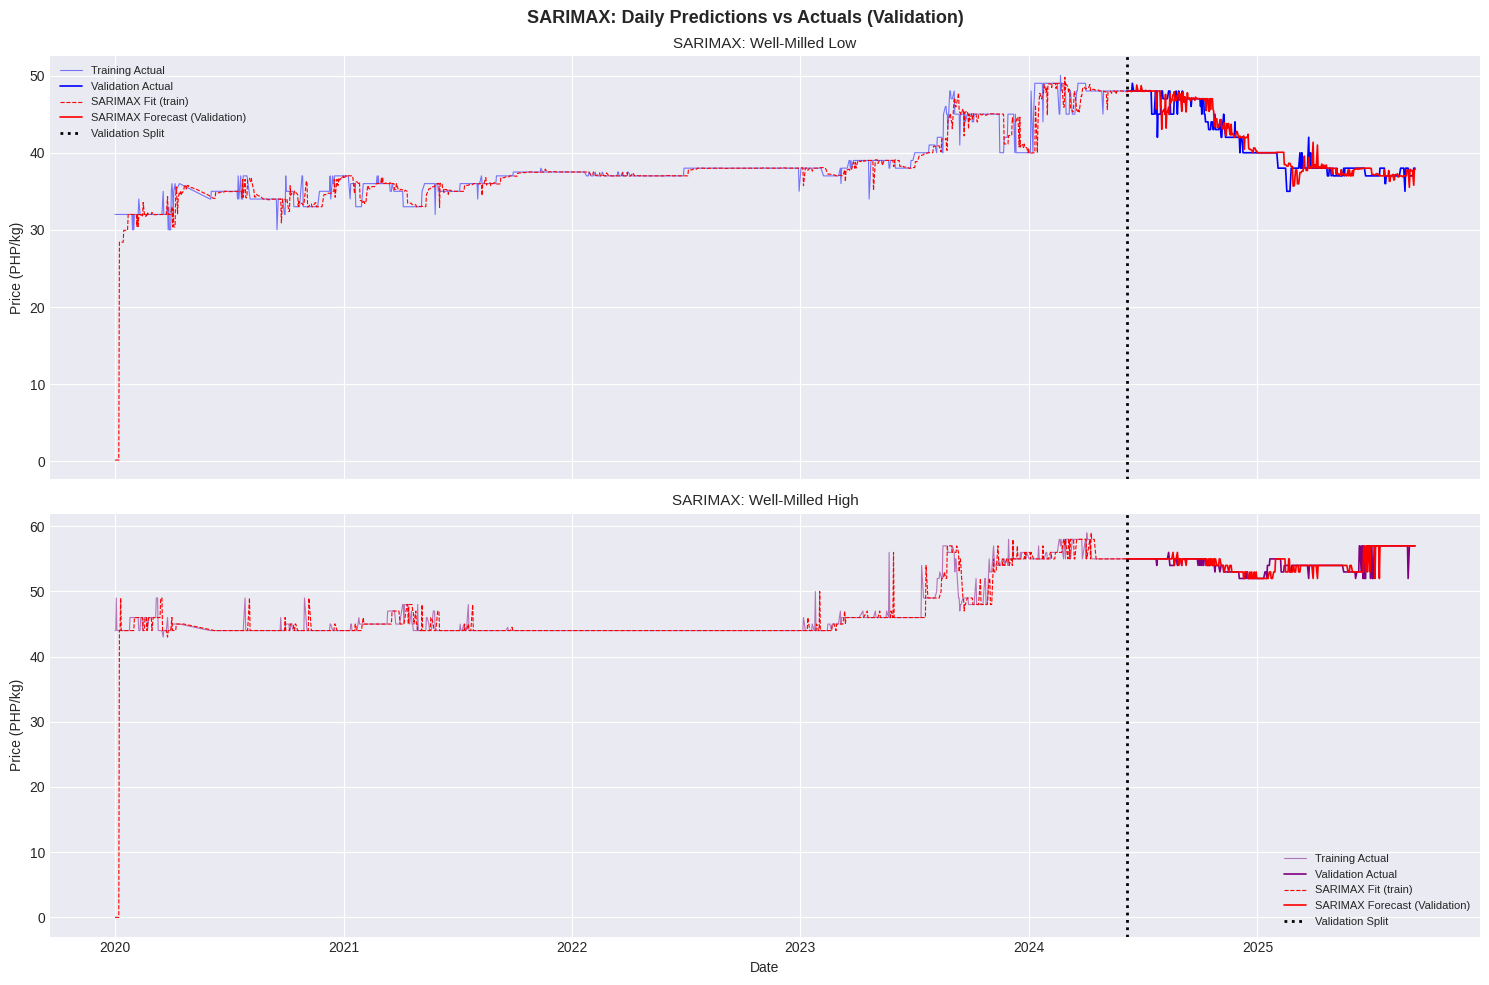

In [ ]:
# Visualise SARIMAX fit for Well-Milled Low and High
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot Configuration: Forecasted Well-Milled Low & High
for ax, target, color in zip(axes, FORECAST_TARGETS, TARGET_COLORS):
    res = sarimax_results[target]

    ax.plot(train_rice_df.index, train_rice_df[target], label='Training Actual', color=color, alpha=0.5, linewidth=0.8)
    ax.plot(val_rice_df.index, val_rice_df[target],  label='Validation Actual', color=color, linewidth=1.2)
    ax.plot(train_rice_df.index, res['fitted_train'], label='SARIMAX Fit (train)', color='red', linewidth=0.8, linestyle='--')
    ax.plot(val_rice_df.index, res['forecast_val'], label='SARIMAX Forecast (Validation)', color='red', linewidth=1.2)
    ax.axvline(val_rice_df.index[0], color='black', linestyle=':', linewidth=2, label='Validation Split')
    ax.set_title(f'SARIMAX: {target}', fontsize=11)
    ax.set_ylabel('Price (PHP/kg)')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Date')
plt.suptitle('SARIMAX: Daily Predictions vs Actuals (Validation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

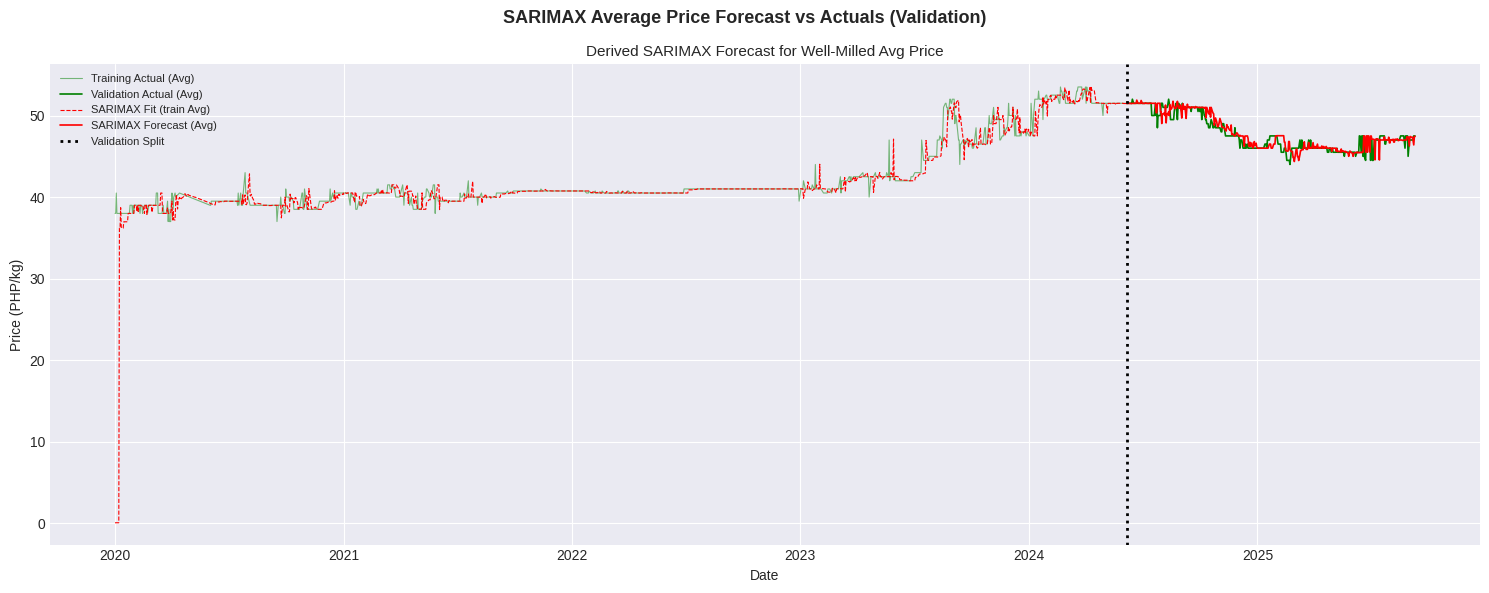

In [ ]:
# Calculate forecasted average from forecasted low and high prices
forecasted_avg_val = (sarimax_results['Well-Milled Low']['forecast_val'] + sarimax_results['Well-Milled High']['forecast_val']) / 2

# Calculate fitted average for training data
fitted_avg_train = (sarimax_results['Well-Milled Low']['fitted_train'] + sarimax_results['Well-Milled High']['fitted_train']) / 2

# Plot Configurations: Forecasted Well-Milled Avg
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(train_rice_df.index, train_rice_df['Well-Milled Avg'], label='Training Actual (Avg)', color='green', alpha=0.5, linewidth=0.8)
ax.plot(val_rice_df.index, val_rice_df['Well-Milled Avg'], label='Validation Actual (Avg)', color='green', linewidth=1.2)
ax.plot(fitted_avg_train.index, fitted_avg_train, label='SARIMAX Fit (train Avg)', color='red', linewidth=0.8, linestyle='--')
ax.plot(forecasted_avg_val.index, forecasted_avg_val, label='SARIMAX Forecast (Avg)', color='red', linewidth=1.2)
ax.axvline(val_rice_df.index[0], color='black', linestyle=':', linewidth=2, label='Validation Split')

ax.set_title('Derived SARIMAX Forecast for Well-Milled Avg Price', fontsize=11)
ax.set_ylabel('Price (PHP/kg)')
ax.set_xlabel('Date')
ax.legend(fontsize=8)

plt.suptitle('SARIMAX Average Price Forecast vs Actuals (Validation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**SARIMAX Forecast Residuals**
A visualization of the residuals of the SARIMAX forecast across the Well-Milled High and Low on each of the training and validation sets.

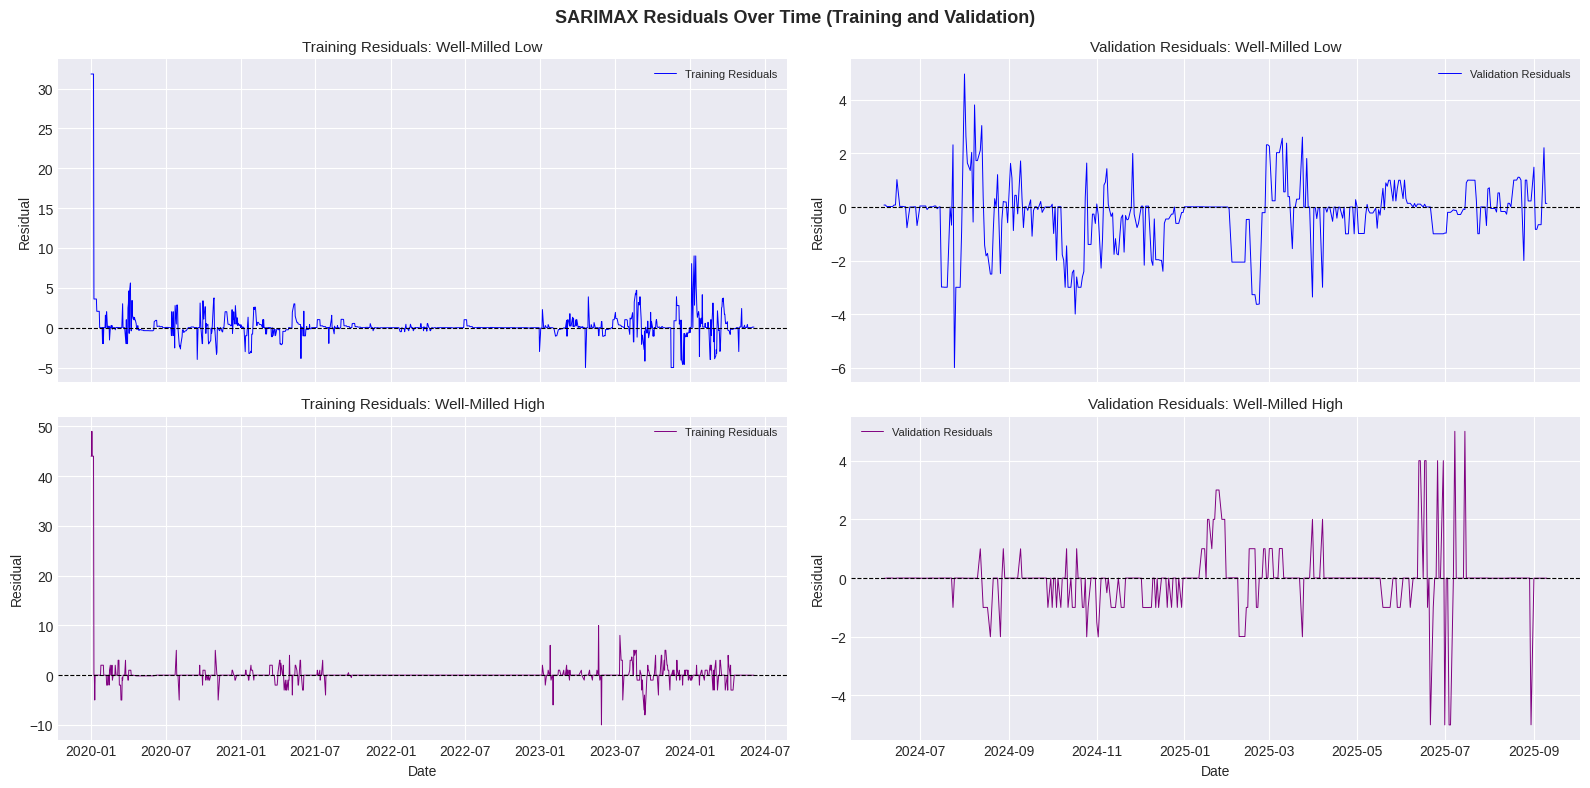

In [ ]:
fig, axes = plt.subplots(len(FORECAST_TARGETS), 2, figsize=(16, 8), sharex='col') # 2 rows (targets), 2 cols (train_resid, val_resid)

for i, target in enumerate(FORECAST_TARGETS):
    train_resid = sarimax_results[target]['train_resid']
    val_resid = sarimax_results[target]['val_resid']
    color = TARGET_COLORS[i]

    # Training Set Residuals
    axes[i, 0].plot(train_resid.index, train_resid, label='Training Residuals', color=color, linewidth=0.7)
    axes[i, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i, 0].set_title(f'Training Residuals: {target}', fontsize=11)
    axes[i, 0].set_ylabel('Residual')
    axes[i, 0].legend(fontsize=8)

    # Validation Set Residuals
    axes[i, 1].plot(val_resid.index, val_resid, label='Validation Residuals', color=color, linewidth=0.7)
    axes[i, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i, 1].set_title(f'Validation Residuals: {target}', fontsize=11)
    axes[i, 1].set_ylabel('Residual')
    axes[i, 1].legend(fontsize=8)

axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')

plt.suptitle('SARIMAX Residuals Over Time (Training and Validation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Individual SARIMAX Residual Plots**

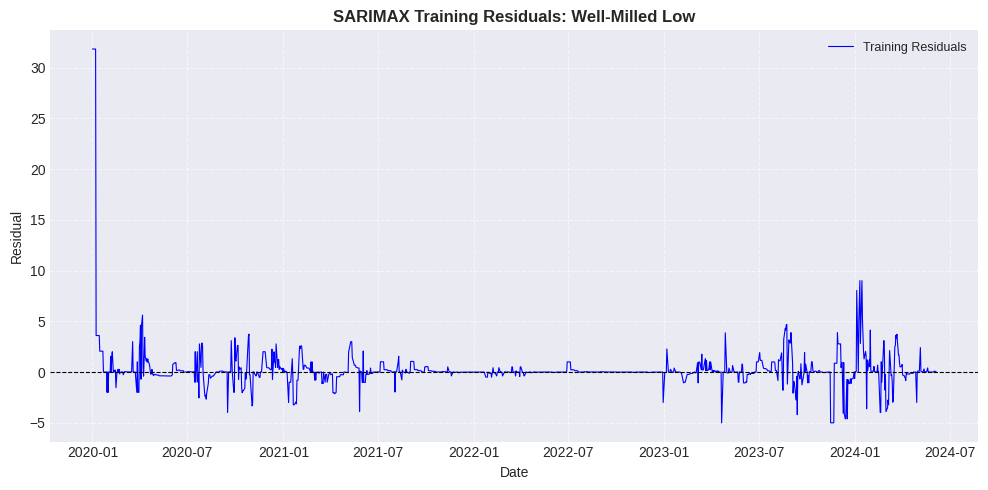

In [ ]:
target = 'Well-Milled Low'
train_resid = sarimax_results[target]['train_resid']
color = TARGET_COLORS[FORECAST_TARGETS.index(target)]

# Plot Training Residuals for Well-Milled Low
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_resid.index, train_resid, label='Training Residuals', color=color, linewidth=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'SARIMAX Training Residuals: {target}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

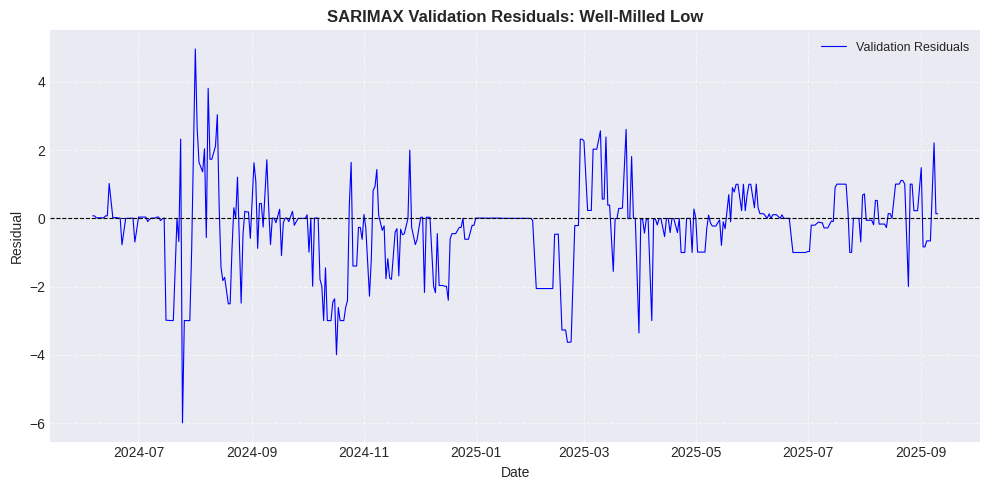

In [ ]:
target = 'Well-Milled Low'
val_resid = sarimax_results[target]['val_resid']
color = TARGET_COLORS[FORECAST_TARGETS.index(target)]

# Plot Validation Residuals for Well-Milled Low
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(val_resid.index, val_resid, label='Validation Residuals', color=color, linewidth=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'SARIMAX Validation Residuals: {target}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

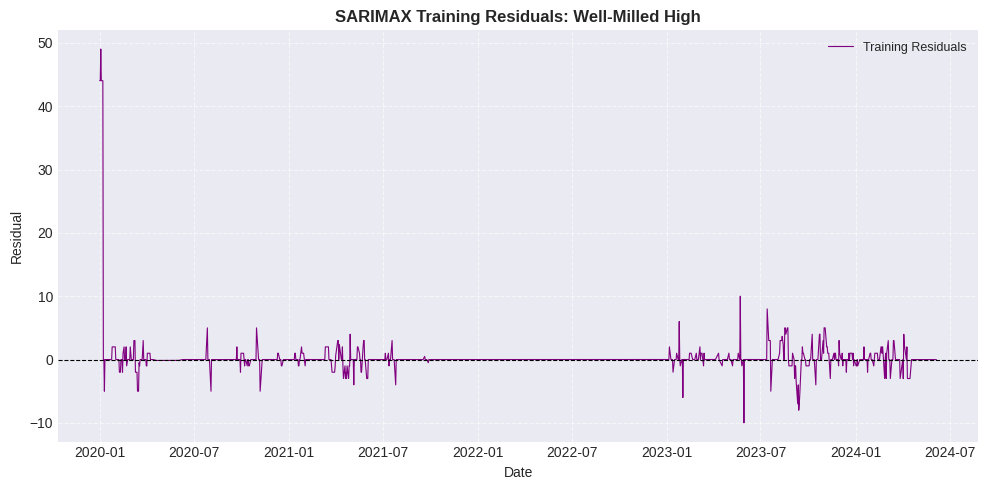

In [ ]:
target = 'Well-Milled High'
train_resid = sarimax_results[target]['train_resid']
color = TARGET_COLORS[FORECAST_TARGETS.index(target)]

# Plot Training Residuals for Well-Milled High
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_resid.index, train_resid, label='Training Residuals', color=color, linewidth=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'SARIMAX Training Residuals: {target}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

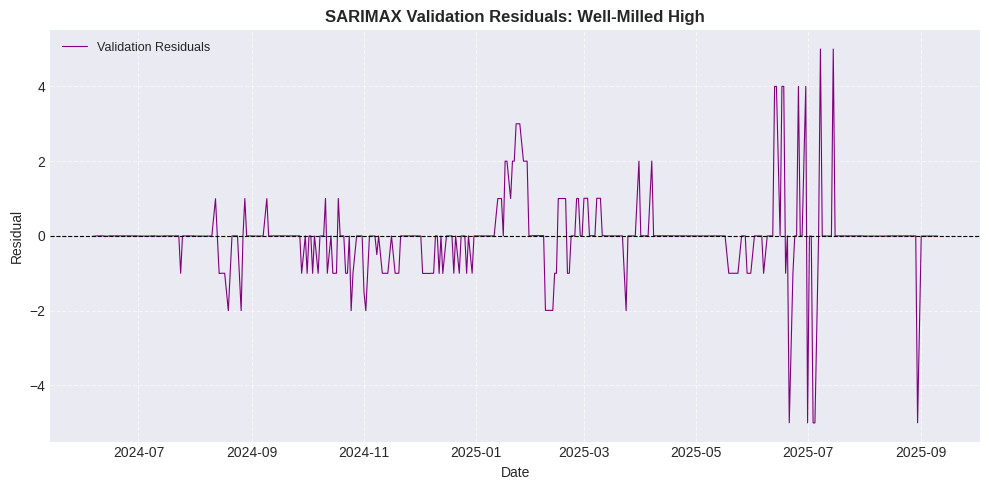

In [ ]:
target = 'Well-Milled High'
val_resid = sarimax_results[target]['val_resid']
color = TARGET_COLORS[FORECAST_TARGETS.index(target)]

# Plot Validation Residuals for Well-Milled High
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(val_resid.index, val_resid, label='Validation Residuals', color=color, linewidth=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'SARIMAX Validation Residuals: {target}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **SARIMAX RESIDUALS EXPORT**

Downloading the calculated training and validation residuals from the SARIMAX model for further analysis or use.

In [ ]:
# Directory to save residuals
residuals_dir = 'sarimax_residuals'
os.makedirs(residuals_dir, exist_ok=True)

for target in FORECAST_TARGETS:
    # Save training residuals
    train_resid_path = os.path.join(residuals_dir, f'sarimax_train_residuals_{target.replace(" ", "_")}.csv')
    sarimax_results[target]['train_resid'].to_csv(train_resid_path)
    print(f'Training residuals for "{target}" saved to {train_resid_path}')

    # Save validation residuals
    val_resid_path = os.path.join(residuals_dir, f'sarimax_val_residuals_{target.replace(" ", "_")}.csv')
    sarimax_results[target]['val_resid'].to_csv(val_resid_path)
    print(f'Validation residuals for "{target}" saved to {val_resid_path}')

Training residuals for "Well-Milled Low" saved to sarimax_residuals/sarimax_train_residuals_Well-Milled_Low.csv
Validation residuals for "Well-Milled Low" saved to sarimax_residuals/sarimax_val_residuals_Well-Milled_Low.csv
Training residuals for "Well-Milled High" saved to sarimax_residuals/sarimax_train_residuals_Well-Milled_High.csv
Validation residuals for "Well-Milled High" saved to sarimax_residuals/sarimax_val_residuals_Well-Milled_High.csv


### **SARIMAX MODEL EXPORT**

Saving the trained SARIMAX models for future use.

In [ ]:
# Directory to save models
model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

for target in FORECAST_TARGETS:
    # Save SARIMAX model
    sarimax_model_path = os.path.join(model_dir, f'sarimax_model_{target.replace(" ", "_")}.pkl')
    sarimax_results[target]['model_fit'].save(sarimax_model_path)
    print(f'SARIMAX model for "{target}" saved to {sarimax_model_path}')

SARIMAX model for "Well-Milled Low" saved to models/sarimax_model_Well-Milled_Low.pkl
SARIMAX model for "Well-Milled High" saved to models/sarimax_model_Well-Milled_High.pkl
